# Lab 1 — Intro to Behavioral TV Data
Name: Дарина Джура | Group: КМ - 41

## Setup

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Download dataset via kagglehub
DATA = kagglehub.dataset_download("shkarupylomaxim/adtech-lab1-tv-panel/versions/2")

programs = pd.read_parquet(f"{DATA}/programs.parquet")
viewings = pd.read_parquet(f"{DATA}/viewings.parquet")
daily_weights = pd.read_parquet(f"{DATA}/daily_weights.parquet")
viewer_attributes = pd.read_parquet(f"{DATA}/viewer_attributes.parquet")
attributes = pd.read_parquet(f"{DATA}/attributes.parquet")

# Parse datetime columns and broadcast dates
programs['start_ts'] = pd.to_datetime(programs['start_ts'])
programs['end_ts'] = pd.to_datetime(programs['end_ts'])
programs['broadcast_date'] = pd.to_datetime(programs['broadcast_date']).dt.date

viewings['start_ts'] = pd.to_datetime(viewings['start_ts'])
viewings['end_ts'] = pd.to_datetime(viewings['end_ts'])

daily_weights['broadcast_date'] = pd.to_datetime(daily_weights['broadcast_date']).dt.date

# Compute average monthly weight for each in-tab respondent (rule for Reach and Frequency)
monthly_weights = (
    daily_weights.groupby(['respondent_id', 'resp_type'])['weight']
    .mean()
    .reset_index()
)
monthly_weights_dict = dict(zip(monthly_weights['respondent_id'], monthly_weights['weight']))

print("Setup completed successfully.")

Using Colab cache for faster access to the 'adtech-lab1-tv-panel' dataset.
Setup completed successfully.


## Task 1.1 — Panel and universe

In [2]:
# Decode attribute codes
codes = [101, 102, 103, 104, 201, 202, 300]
display(attributes[attributes['attr_id'].isin(codes)])

va_named = viewer_attributes.merge(attributes, on='attr_id', how='left')
print("Codes without a name:", va_named['attr_name'].isna().sum())
print("Row count unchanged after merge:", len(va_named) == len(viewer_attributes))
display(va_named.head())

# Age (numeric code 300 -> value)
age_df = (
    va_named[va_named['attr_id'] == 300][['respondent_id', 'value']]
    .rename(columns={'value': 'age'})
)

# Sex, decoded by name from the 'Sex' attribute group
sex_df = va_named[va_named['attr_group'] == 'Sex'][['respondent_id', 'attr_name']].copy()
name = sex_df['attr_name'].str.lower()
sex_df['sex'] = np.where(name.str.startswith('female'), 'W',
                 np.where(name.str.startswith('male'), 'M', None))
sex_df = sex_df[['respondent_id', 'sex']]
print("Sex names found:", va_named[va_named['attr_group'] == 'Sex']['attr_name'].unique())

# Demographic lookup for persons (R, L) with monthly weight
person_weights = monthly_weights[monthly_weights['resp_type'].isin(['R', 'L'])]
demo_df = (
    person_weights[['respondent_id', 'resp_type', 'weight']]
    .merge(age_df, on='respondent_id', how='inner')
    .merge(sex_df, on='respondent_id', how='inner')
)

# Checks
print("Unique respondent_id:", demo_df['respondent_id'].is_unique)
print("Persons in demo_df:", len(demo_df), "| persons in daily_weights:", daily_weights[daily_weights['resp_type'].isin(['R', 'L'])]['respondent_id'].nunique())
print("Missing values:\n", demo_df.isna().sum())
print(demo_df['sex'].value_counts())

,attr_id,attr_group,attr_name,value_type,applies_to
0,101,Respondent type,R: panel member (household member),flag,"H,R,L,S"
1,102,Respondent type,L: long-term visitor,flag,"H,R,L,S"
2,103,Respondent type,"S: short-term visitor (guest); id ends 81, 82,...",flag,"H,R,L,S"
3,104,Respondent type,H: household record (id ending 00),flag,"H,R,L,S"
4,201,Sex,Male,flag,"R,L,S"
5,202,Sex,Female,flag,"R,L,S"
6,300,Age,Age in years,numeric,"R,L"


Codes without a name: 0
Row count unchanged after merge: True


,respondent_id,attr_id,value,attr_group,attr_name,value_type,applies_to
0,10000100,104,NaN,Respondent type,H: household record (id ending 00),flag,"H,R,L,S"
1,10000100,802,NaN,Household size,2 persons,flag,H
2,10000100,815,NaN,Household income,$100k-$150k,flag,H
3,10000100,822,NaN,Children in household,No children under 18,flag,H
4,10000100,833,NaN,TV reception,Telco / fiber,flag,H


Sex names found: ['Female' 'Male']
Unique respondent_id: True
Persons in demo_df: 10210 | persons in daily_weights: 10210
Missing values:
 respondent_id    0
resp_type        0
weight           0
age              0
sex              0
dtype: int64
sex
W    5105
M    5105
Name: count, dtype: int64


In [3]:
dw_h = daily_weights[daily_weights['resp_type'] == 'H']
dw_p = daily_weights[daily_weights['resp_type'].isin(['R', 'L'])]

# Who is registered in viewer_attributes vs who was in-tab in daily_weights
va_h = set(viewer_attributes.loc[viewer_attributes['attr_id'] == 104, 'respondent_id'])
va_p = set(viewer_attributes.loc[viewer_attributes['attr_id'].isin([101, 102]), 'respondent_id'])

dw_h_ids = set(dw_h['respondent_id'])
dw_p_ids = set(dw_p['respondent_id'])

print("Households in viewer_attributes:", len(va_h))
print("Households in daily_weights:", len(dw_h_ids))
print("Households registered but never in-tab:", len(va_h - dw_h_ids))
print("Households in-tab but not in viewer_attributes:", len(dw_h_ids - va_h))

print("Persons in viewer_attributes:", len(va_p))
print("Persons in daily_weights:", len(dw_p_ids))
print("Persons registered but never in-tab:", len(va_p - dw_p_ids))
print("Persons in-tab but not in viewer_attributes:", len(dw_p_ids - va_p))

# Do the never-in-tab people appear in viewings at all?
never_in_tab = (va_h - dw_h_ids) | (va_p - dw_p_ids)
print("Never-in-tab ids that appear in viewings:",
      viewings['respondent_id'].isin(never_in_tab).sum(), "sessions")

# Viewing ids missing from daily_weights, by respondent type
missing = viewings[~viewings['respondent_id'].isin(daily_weights['respondent_id'])]
print("Viewing sessions from ids not in daily_weights, by type:")
print(missing['resp_type'].value_counts())

# How many in-tab days each respondent has (partial presence = joined or left mid-month)
n_days_total = daily_weights['broadcast_date'].nunique()
days_per_resp = daily_weights.groupby('respondent_id')['broadcast_date'].nunique()
print("Broadcast days in the month:", n_days_total)
print("Respondents in-tab all days:", (days_per_resp == n_days_total).sum())
print("Respondents in-tab only part of the month:", (days_per_resp < n_days_total).sum())

Households in viewer_attributes: 4256
Households in daily_weights: 4254
Households registered but never in-tab: 2
Households in-tab but not in viewer_attributes: 0
Persons in viewer_attributes: 10216
Persons in daily_weights: 10210
Persons registered but never in-tab: 6
Persons in-tab but not in viewer_attributes: 0
Never-in-tab ids that appear in viewings: 0 sessions
Viewing sessions from ids not in daily_weights, by type:
resp_type
S    11996
Name: count, dtype: int64
Broadcast days in the month: 31
Respondents in-tab all days: 4824
Respondents in-tab only part of the month: 9640


In [4]:
n_telecasts = programs['telecast_id'].nunique()
n_programs = programs['program_name'].nunique()
n_networks = programs['network_code'].nunique()

hh_in_panel = dw_h['respondent_id'].nunique()
p_in_panel = dw_p['respondent_id'].nunique()

hh_daily = dw_h.groupby('broadcast_date').agg(count=('respondent_id', 'count'), weight=('weight', 'sum'))
p_daily = dw_p.groupby('broadcast_date').agg(count=('respondent_id', 'count'), weight=('weight', 'sum'))

print("Telecasts:", n_telecasts)
print("Programs:", n_programs)
print("Networks:", n_networks)
print("Households in panel:", hh_in_panel)
print("Persons in panel:", p_in_panel)
print("Households in-tab, average day:", round(hh_daily['count'].mean(), 1))
print("Persons in-tab, average day:", round(p_daily['count'].mean(), 1))
print("US TV households represented, average day (M):", round(hh_daily['weight'].mean() / 1e6, 2))
print("US persons represented, average day (M):", round(p_daily['weight'].mean() / 1e6, 2))

Telecasts: 5841
Programs: 246
Networks: 10
Households in panel: 4254
Persons in panel: 10210
Households in-tab, average day: 3878.5
Persons in-tab, average day: 9268.7
US TV households represented, average day (M): 125.8
US persons represented, average day (M): 317.28


**Answer:** `viewer_attributes` is a registry of everyone enrolled in the panel: it lists 4,256 households and 10,216 persons, while `daily_weights` contains 4,254 households and 10,210 persons. The difference is 2 households and 6 persons who were registered but were never in-tab on any broadcast day of October, so they have no weight and no viewing sessions (none of their ids appear in `viewings`). In the other direction, nobody who is in-tab is missing from the registry (0 households and 0 persons). `daily_weights` therefore describes only respondents who were actually measured on a given broadcast day, which is exactly what we need to project audiences to the US universe. It also shows that panel membership changes during the month: only 4,824 respondents are in-tab on all 31 broadcast days, while 9,640 are in-tab on only part of the month (they joined, left or had a meter failure), which is why daily weights are re-balanced every day.

## Task 1.2 — Average audience by hour of day

Broadcast dates in sessions but not in daily_weights: []
Sessions dropped: 0
Longest session (min): 388.0
Weighted minutes, sessions (M): 561429.0
Weighted minutes, hour chunks (M): 561429.0
Weekdays: 23 | Weekend days: 8


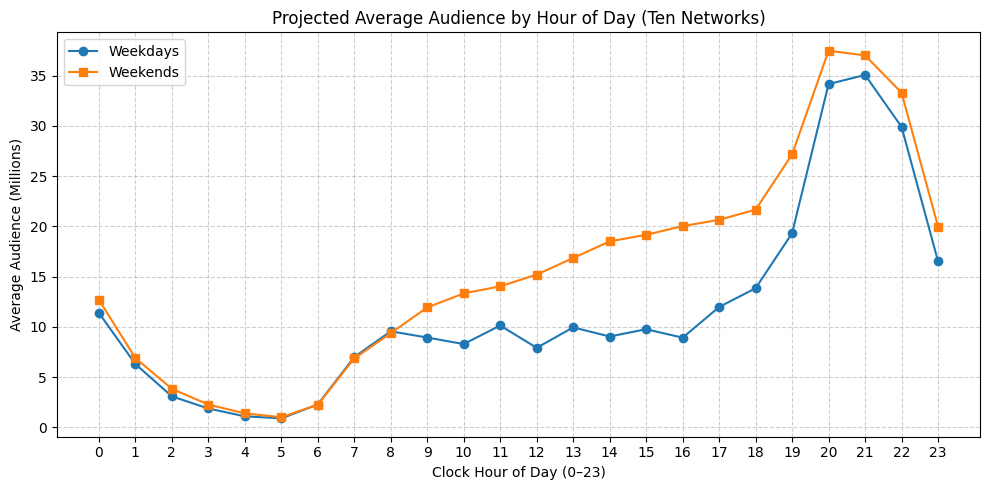

Peak hour, weekdays: 21:00
Peak hour, weekends: 20:00
Weekday audience at 14:00 (M): 9.03
Weekend audience at 14:00 (M): 18.51


In [5]:
# Person sessions (R, L)
pv = viewings[viewings['resp_type'].isin(['R', 'L'])].copy()
pv['broadcast_date'] = (pv['start_ts'] - pd.Timedelta(hours=6)).dt.date

# Sessions whose broadcast day is not in daily_weights (e.g. 00:00-05:59 on Oct 1 -> Sep 30)
valid_days = set(daily_weights['broadcast_date'])
print("Broadcast dates in sessions but not in daily_weights:",
      sorted(set(pv['broadcast_date']) - valid_days))
print("Sessions dropped:", (~pv['broadcast_date'].isin(valid_days)).sum())
pv = pv[pv['broadcast_date'].isin(valid_days)].copy()

pv['dur'] = (pv['end_ts'] - pv['start_ts']).dt.total_seconds() / 60.0
print("Longest session (min):", round(pv['dur'].max(), 1))

# Split every session into clock-hour chunks (including hours after midnight)
first_hour = pv['start_ts'].dt.floor('h')
max_k = int(np.ceil(pv['dur'].max() / 60)) + 1
chunks = []
for k in range(max_k + 1):
    h_start = first_hour + pd.Timedelta(hours=k)
    h_end = h_start + pd.Timedelta(hours=1)
    o_start = np.maximum(pv['start_ts'], h_start)
    o_end = np.minimum(pv['end_ts'], h_end)
    mins = (o_end - o_start).dt.total_seconds() / 60.0
    m = mins > 0
    if not m.any():
        continue
    chunks.append(pd.DataFrame({
        'hour': h_start[m].dt.hour,
        'bdate': (h_start[m] - pd.Timedelta(hours=6)).dt.date,  # broadcast day of this clock hour
        'wmin': mins[m] * pv.loc[m, 'weight']
    }))

hour_df = pd.concat(chunks, ignore_index=True)
hour_df = hour_df[hour_df['bdate'].isin(valid_days)]
hour_df['is_weekend'] = pd.to_datetime(hour_df['bdate']).dt.dayofweek >= 5

# Sanity check: weighted minutes before and after splitting
print("Weighted minutes, sessions (M):", round((pv['dur'] * pv['weight']).sum() / 1e6, 1))
print("Weighted minutes, hour chunks (M):", round(hour_df['wmin'].sum() / 1e6, 1))

# Number of weekdays / weekend days by broadcast day
days = pd.Series(sorted(valid_days))
is_we = pd.to_datetime(days).dt.dayofweek >= 5
n_weekdays, n_weekends = int((~is_we).sum()), int(is_we.sum())
print("Weekdays:", n_weekdays, "| Weekend days:", n_weekends)

# Average audience per minute (M) = weighted minutes / (60 * days)
hourly = (hour_df.groupby(['hour', 'is_weekend'])['wmin'].sum()
          .unstack(fill_value=0).reindex(range(24), fill_value=0))
for col in [False, True]:
    if col not in hourly.columns:
        hourly[col] = 0.0
hourly[False] = hourly[False] / (60.0 * n_weekdays * 1e6)
hourly[True] = hourly[True] / (60.0 * n_weekends * 1e6)

peak_hour_wd = int(hourly[False].idxmax())
peak_hour_we = int(hourly[True].idxmax())

plt.figure(figsize=(10, 5))
plt.plot(hourly.index, hourly[False], marker='o', label='Weekdays', color='#1f77b4')
plt.plot(hourly.index, hourly[True], marker='s', label='Weekends', color='#ff7f0e')
plt.title('Projected Average Audience by Hour of Day (Ten Networks)')
plt.xlabel('Clock Hour of Day (0–23)')
plt.ylabel('Average Audience (Millions)')
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print("Peak hour, weekdays:", f"{peak_hour_wd}:00")
print("Peak hour, weekends:", f"{peak_hour_we}:00")
print("Weekday audience at 14:00 (M):", round(hourly.loc[14, False], 2))
print("Weekend audience at 14:00 (M):", round(hourly.loc[14, True], 2))

**Answer:** On weekdays the audience is concentrated in prime time: it climbs from about 9-10 million viewers per minute during the working day (8:00-16:00) to a peak of about 35 million at 21:00. On weekends the peak is one hour earlier, at 20:00, and slightly higher (about 37.5 million). The main difference is the daytime: the weekend audience grows steadily from 8:00 and reaches about 18.5 million at 14:00, twice the weekday level of 9.0 million at the same hour, because people are at home and watch daytime content such as sports. In the evening (20:00-22:00) the two curves are much closer, and from 2:00 to 7:00 they almost coincide at a very low level of 1-4 million. Weekends also have slightly higher late-night audience (0:00-1:00).

## Task 1.3 — Session length

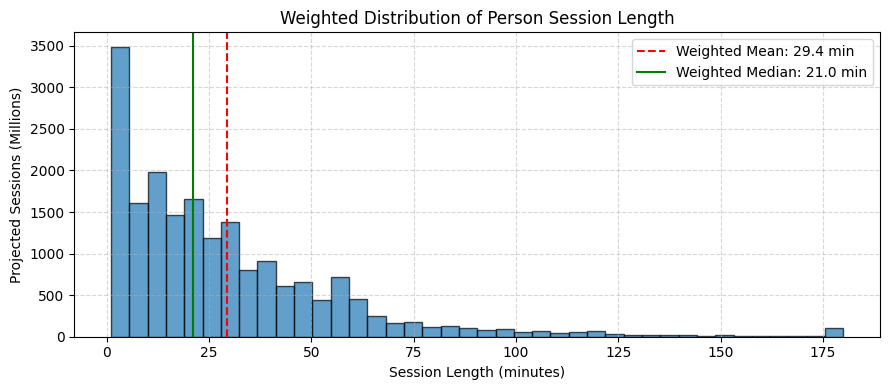

Session length, weighted mean (min): 29.4
Session length, weighted median (min): 21.0


In [6]:
# Filter viewing sessions for persons (R and L)
p_views = viewings[viewings['resp_type'].isin(['R', 'L'])].copy()
p_views['duration'] = (p_views['end_ts'] - p_views['start_ts']).dt.total_seconds() / 60.0

# Weighted mean calculation: sum(duration * weight) / sum(weight)
w_mean = (p_views['duration'] * p_views['weight']).sum() / p_views['weight'].sum()

# Weighted median calculation using cumulative weight distribution
sorted_pv = p_views.sort_values('duration')
cum_weights = sorted_pv['weight'].cumsum()
cutoff = sorted_pv['weight'].sum() / 2.0
w_median = sorted_pv.loc[cum_weights >= cutoff, 'duration'].iloc[0]

# Plot weighted session length distribution (clipped at 180 min for readability)
plt.figure(figsize=(9, 4))
plt.hist(p_views['duration'].clip(upper=180), bins=40, weights=p_views['weight'] / 1e6, edgecolor='black', alpha=0.7)
plt.axvline(w_mean, color='red', linestyle='--', label=f'Weighted Mean: {w_mean:.1f} min')
plt.axvline(w_median, color='green', linestyle='-', label=f'Weighted Median: {w_median:.1f} min')
plt.title('Weighted Distribution of Person Session Length')
plt.xlabel('Session Length (minutes)')
plt.ylabel('Projected Sessions (Millions)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Session length, weighted mean (min):", round(w_mean, 1))
print("Session length, weighted median (min):", round(w_median, 1))

**Answer:** The weighted mean session length is 29.4 minutes, while the weighted median is 21.0 minutes. The mean is higher because the distribution is right-skewed: most sessions are relatively short, but there is a long tail of very long sessions (the histogram has a tail up to 180 minutes and more), and these few long sessions pull the mean up, while the median is not affected by them. In a client deck I would show the median (21 minutes) as the length of a typical viewing session, because the mean overstates what a typical viewer does. The mean is still useful when we need totals, because mean session length × number of sessions gives total viewing minutes.

## Task 2 — Program reach curve

,Telecast,Date,HH rating (%),P2+ rating (%),Audience (M),Cum. reach P2+ (%),Cum. reach A18-34 (%),Cum. reach A18-49 (%)
0,1003837,2024-10-01,3.5,1.7,5.28,1.5,0.1,0.4
1,1003857,2024-10-02,3.1,1.5,4.68,2.4,0.2,0.6
2,1003877,2024-10-03,3.0,1.5,4.68,2.9,0.3,0.8
3,1003896,2024-10-04,3.0,1.5,4.81,3.3,0.4,1.0
4,1003936,2024-10-07,3.1,1.5,4.83,3.8,0.7,1.1
5,1003952,2024-10-08,3.2,1.6,4.97,4.3,0.9,1.3
6,1003970,2024-10-09,3.0,1.5,4.70,4.7,0.9,1.4
7,1003985,2024-10-10,3.4,1.6,5.13,5.2,1.0,1.7
8,1004001,2024-10-11,3.1,1.5,4.69,5.5,1.1,1.9
9,1004040,2024-10-14,2.9,1.4,4.59,5.8,1.2,2.1


Rows (telecasts): 23
Reach P2+ never decreases: True
Reach A18-34 <= A18-49 everywhere: True
Rating range P2+ (%): 1.3 - 1.8


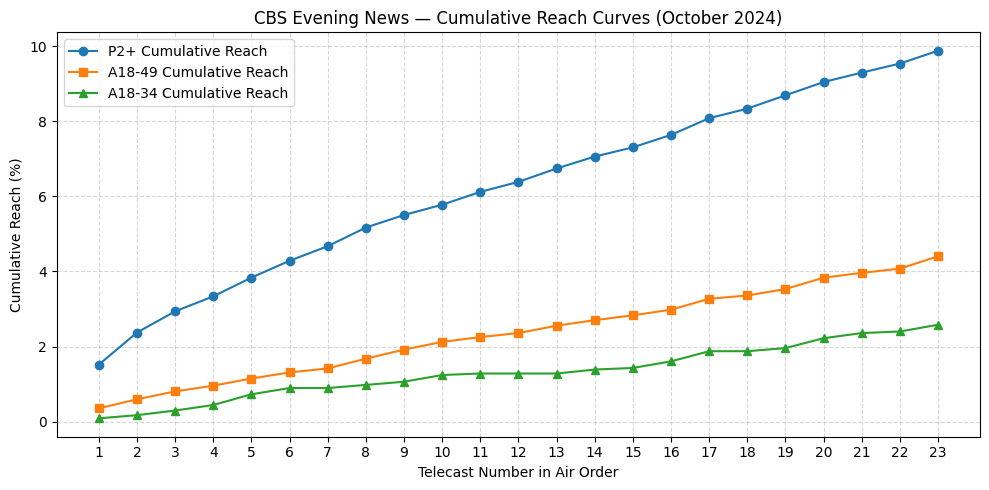

Telecasts of the program: 23
Average household rating (%): 3.2
Average P2+ rating (%): 1.6
Average projected audience (M): 4.93
Final reach P2+ (%): 9.9
Final reach A18-34 (%): 2.6
Final reach A18-49 (%): 4.4


In [7]:
# Filter all October telecasts of CBS Evening News sorted by air time
cbs_news = programs[
    (programs['network_code'] == 'CBS') &
    (programs['program_name'] == 'CBS Evening News')
].sort_values('start_ts').copy()

# Separate viewing sessions for Households (H) and Persons (R, L)
vw_cbs = viewings[viewings['network_code'] == 'CBS'].copy()
vw_h = vw_cbs[vw_cbs['resp_type'] == 'H']
vw_p = vw_cbs[vw_cbs['resp_type'].isin(['R', 'L'])].merge(
    demo_df[['respondent_id', 'age']], on='respondent_id', how='left'
)

# Daily in-tab universe weights for ratings denominators
daily_univ_h = dw_h.groupby('broadcast_date')['weight'].sum().to_dict()
daily_univ_p2 = dw_p.groupby('broadcast_date')['weight'].sum().to_dict()

# Monthly weight totals for cumulative reach denominators (rules for lab)
sum_mw_p2 = demo_df['weight'].sum()
sum_mw_a1834 = demo_df[(demo_df['age'] >= 18) & (demo_df['age'] <= 34)]['weight'].sum()
sum_mw_a1849 = demo_df[(demo_df['age'] >= 18) & (demo_df['age'] <= 49)]['weight'].sum()

seen_p2 = set()
seen_a1834 = set()
seen_a1849 = set()

telecast_rows = []
reach_p2_curve = []
reach_a1834_curve = []
reach_a1849_curve = []

for idx, t in cbs_news.iterrows():
    t_start, t_end, b_date = t['start_ts'], t['end_ts'], t['broadcast_date']

    # Household viewing (at least 1 minute overlap)
    h_overlap = (np.minimum(vw_h['end_ts'], t_end) - np.maximum(vw_h['start_ts'], t_start)).dt.total_seconds() / 60.0
    h_watchers = vw_h[h_overlap >= 1.0].drop_duplicates(subset=['respondent_id'])
    hh_rating = (h_watchers['weight'].sum() / daily_univ_h[b_date]) * 100.0

    # Persons viewing (at least 1 minute overlap)
    p_overlap = (np.minimum(vw_p['end_ts'], t_end) - np.maximum(vw_p['start_ts'], t_start)).dt.total_seconds() / 60.0
    p_watchers = vw_p[p_overlap >= 1.0].drop_duplicates(subset=['respondent_id'])

    p2_rating = (p_watchers['weight'].sum() / daily_univ_p2[b_date]) * 100.0
    projected_aud_m = p_watchers['weight'].sum() / 1e6

    telecast_rows.append({
        'telecast_id': t['telecast_id'],
        'date': b_date,
        'hh_rating': hh_rating,
        'p2_rating': p2_rating,
        'projected_aud_m': projected_aud_m
    })

    # Update cumulative reach sets
    watchers_p2 = set(p_watchers['respondent_id'])
    watchers_1834 = set(p_watchers[(p_watchers['age'] >= 18) & (p_watchers['age'] <= 34)]['respondent_id'])
    watchers_1849 = set(p_watchers[(p_watchers['age'] >= 18) & (p_watchers['age'] <= 49)]['respondent_id'])

    seen_p2.update(watchers_p2)
    seen_a1834.update(watchers_1834)
    seen_a1849.update(watchers_1849)

    reach_p2_curve.append((sum(monthly_weights_dict[rid] for rid in seen_p2) / sum_mw_p2) * 100.0)
    reach_a1834_curve.append((sum(monthly_weights_dict[rid] for rid in seen_a1834) / sum_mw_a1834) * 100.0)
    reach_a1849_curve.append((sum(monthly_weights_dict[rid] for rid in seen_a1849) / sum_mw_a1849) * 100.0)

t_results = pd.DataFrame(telecast_rows)

# Per-telecast table: household rating, P2+ rating, projected audience
t_results['reach_p2'] = reach_p2_curve
t_results['reach_a1834'] = reach_a1834_curve
t_results['reach_a1849'] = reach_a1849_curve

table = t_results.rename(columns={
    'telecast_id': 'Telecast',
    'date': 'Date',
    'hh_rating': 'HH rating (%)',
    'p2_rating': 'P2+ rating (%)',
    'projected_aud_m': 'Audience (M)',
    'reach_p2': 'Cum. reach P2+ (%)',
    'reach_a1834': 'Cum. reach A18-34 (%)',
    'reach_a1849': 'Cum. reach A18-49 (%)'
}).round({
    'HH rating (%)': 1, 'P2+ rating (%)': 1, 'Audience (M)': 2,
    'Cum. reach P2+ (%)': 1, 'Cum. reach A18-34 (%)': 1, 'Cum. reach A18-49 (%)': 1
})
display(table)

# Sanity checks
print("Rows (telecasts):", len(table))
print("Reach P2+ never decreases:", all(np.diff(reach_p2_curve) >= 0))
print("Reach A18-34 <= A18-49 everywhere:",
      all(a <= b for a, b in zip(reach_a1834_curve, reach_a1849_curve)))
print("Rating range P2+ (%):", round(t_results['p2_rating'].min(), 1),
      "-", round(t_results['p2_rating'].max(), 1))

# Plot cumulative reach curves
plt.figure(figsize=(10, 5))
x_ax = range(1, len(cbs_news) + 1)
plt.plot(x_ax, reach_p2_curve, marker='o', label='P2+ Cumulative Reach', color='#1f77b4')
plt.plot(x_ax, reach_a1849_curve, marker='s', label='A18-49 Cumulative Reach', color='#ff7f0e')
plt.plot(x_ax, reach_a1834_curve, marker='^', label='A18-34 Cumulative Reach', color='#2ca02c')
plt.title('CBS Evening News — Cumulative Reach Curves (October 2024)')
plt.xlabel('Telecast Number in Air Order')
plt.ylabel('Cumulative Reach (%)')
plt.xticks(x_ax)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

print("Telecasts of the program:", len(cbs_news))
print("Average household rating (%):", round(t_results['hh_rating'].mean(), 1))
print("Average P2+ rating (%):", round(t_results['p2_rating'].mean(), 1))
print("Average projected audience (M):", round(t_results['projected_aud_m'].mean(), 2))
print("Final reach P2+ (%):", round(reach_p2_curve[-1], 1))
print("Final reach A18-34 (%):", round(reach_a1834_curve[-1], 1))
print("Final reach A18-49 (%):", round(reach_a1849_curve[-1], 1))

**Answer:** A telecast's rating is the share of the audience that watched that one broadcast, so it stays roughly flat (average P2+ rating 1.6%, household rating 3.2%, about 4.93 million viewers per telecast): on any weekday a similar share of the population watches. Cumulative reach, in contrast, counts each person only once over the month, and every new telecast brings in people who have not watched before, so it keeps growing, reaching 9.9% of P2+ after 23 telecasts. The growth slows down towards the end, because the pool of new viewers shrinks and most viewers are repeat viewers. Among the audiences we computed, A18-49 is reached better than A18-34 (4.4% vs 2.6% final reach), and both are well below P2+ (9.9%), so the program reaches the younger audiences much less than the population as a whole. This matches what is known about network evening news: its audience skews strongly towards older viewers (55+), so the reach among young adults is low. Note that P2+ cannot be directly compared with A18-34 or A18-49 as "better" or "worse", because it is a different and much larger group; the comparison is meaningful only between the age targets.

## Task 3 — Program frequency

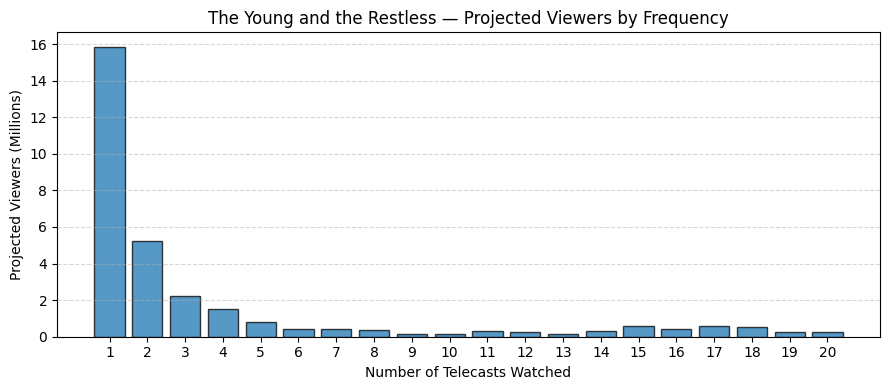

Projected viewers (M): 30.8
Average frequency (weighted): 3.6
Median frequency (weighted): 1
Share of views from the most loyal viewers: 0.704
Number of telecasts of the program: 23
80th percentile of frequency (weighted): 4
Share of viewers with frequency >= P80: 0.243
Share of viewers who watched only once: 0.515


In [8]:
# Filter all October telecasts of The Young and the Restless on CBS
y_r = programs[
    (programs['network_code'] == 'CBS') &
    (programs['program_name'] == 'The Young and the Restless')
].sort_values('start_ts').copy()

# Filter person viewing sessions on CBS
vw_yr = viewings[
    (viewings['network_code'] == 'CBS') &
    (viewings['resp_type'].isin(['R', 'L']))
].copy()

# Count telecasts watched per respondent (>= 1 minute overlap per telecast)
viewer_counts = {}
for _, t in y_r.iterrows():
    t_start, t_end = t['start_ts'], t['end_ts']
    overlap = (np.minimum(vw_yr['end_ts'], t_end) - np.maximum(vw_yr['start_ts'], t_start)).dt.total_seconds() / 60.0
    w_set = set(vw_yr.loc[overlap >= 1.0, 'respondent_id'])
    for rid in w_set:
        viewer_counts[rid] = viewer_counts.get(rid, 0) + 1

# Construct frequency dataframe using monthly weight for each person
freq_df = pd.DataFrame(list(viewer_counts.items()), columns=['respondent_id', 'frequency'])
freq_df['weight'] = freq_df['respondent_id'].map(monthly_weights_dict)

total_proj_viewers_m = freq_df['weight'].sum() / 1e6
w_avg_freq = (freq_df['frequency'] * freq_df['weight']).sum() / freq_df['weight'].sum()

# Weighted median calculation
freq_sorted = freq_df.sort_values('frequency')
cumsum_w = freq_sorted['weight'].cumsum()
w_med_freq = freq_sorted.loc[cumsum_w >= (freq_df['weight'].sum() / 2.0), 'frequency'].iloc[0]

# Weighted 80th percentile threshold (whole frequency levels)
p80_val = freq_sorted.loc[cumsum_w >= (freq_df['weight'].sum() * 0.80), 'frequency'].iloc[0]

# Share of total views from the most loyal viewers
freq_df['projected_views'] = freq_df['frequency'] * freq_df['weight']
loyal_views = freq_df.loc[freq_df['frequency'] >= p80_val, 'projected_views'].sum()
total_views = freq_df['projected_views'].sum()
loyal_share = loyal_views / total_views

# Plot frequency distribution
freq_dist = freq_df.groupby('frequency')['weight'].sum() / 1e6

plt.figure(figsize=(9, 4))
plt.bar(freq_dist.index, freq_dist.values, edgecolor='black', alpha=0.75, color='#1f77b4')
plt.title('The Young and the Restless — Projected Viewers by Frequency')
plt.xlabel('Number of Telecasts Watched')
plt.ylabel('Projected Viewers (Millions)')
plt.xticks(freq_dist.index)
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()

print("Projected viewers (M):", round(total_proj_viewers_m, 2))
print("Average frequency (weighted):", round(w_avg_freq, 1))
print("Median frequency (weighted):", round(w_med_freq, 1))
print("Share of views from the most loyal viewers:", round(loyal_share, 3))

# Extra numbers for the written answer
print("Number of telecasts of the program:", len(y_r))
print("80th percentile of frequency (weighted):", p80_val)
loyal_viewers_share = freq_df.loc[freq_df['frequency'] >= p80_val, 'weight'].sum() / freq_df['weight'].sum()
print("Share of viewers with frequency >= P80:", round(loyal_viewers_share, 3))
print("Share of viewers who watched only once:",
      round(freq_df.loc[freq_df['frequency'] == 1, 'weight'].sum() / freq_df['weight'].sum(), 3))

**Answer:** No, the average frequency is not a fair summary. The weighted average is 3.6 telecasts, but the median is only 1, and 51.5% of the projected 30.8 million viewers watched just one of the 23 telecasts. The distribution is strongly right-skewed: a big group of occasional viewers (about 16 million watched once, about 5 million twice) and a small group of loyal viewers with 14-20 telecasts who pull the mean up. The weighted 80th percentile of frequency is 4, so the most loyal viewers (frequency of 4 or more) are only 24.3% of all viewers, yet they generate 70.4% of all projected views. So the average of 3.6 describes almost nobody: most viewers are far below it and a small loyal core is far above it ("the average can lie"). For an advertiser this means that the audience of a typical telecast is made up of a stable core that sees an ad many times, and a large occasional audience that is reached only once.

## Task 4 — Networks by age and gender

In [9]:
# Person sessions (R, L) with demographics
pv4 = viewings[viewings['resp_type'].isin(['R', 'L'])].copy()
pv4['duration_min'] = (pv4['end_ts'] - pv4['start_ts']).dt.total_seconds() / 60.0
pv4['weighted_min'] = pv4['duration_min'] * pv4['weight']
pv4 = pv4.merge(demo_df[['respondent_id', 'age', 'sex']], on='respondent_id', how='inner')
print("Sessions with demographics:", len(pv4), "of",
      viewings['resp_type'].isin(['R', 'L']).sum())

# Six target audiences
audiences = {
    'M18-34': (pv4['sex'] == 'M') & pv4['age'].between(18, 34),
    'W18-34': (pv4['sex'] == 'W') & pv4['age'].between(18, 34),
    'M35-54': (pv4['sex'] == 'M') & pv4['age'].between(35, 54),
    'W35-54': (pv4['sex'] == 'W') & pv4['age'].between(35, 54),
    'M55+':   (pv4['sex'] == 'M') & (pv4['age'] >= 55),
    'W55+':   (pv4['sex'] == 'W') & (pv4['age'] >= 55),
}

# Six top-5 tables (projected minutes, millions)
for aud_name, mask in audiences.items():
    top5 = (pv4[mask].groupby('network_code')['weighted_min'].sum()
            .nlargest(5).div(1e6).round(2).reset_index())
    top5.columns = ['Network', 'Projected minutes (M)']
    top5.index = range(1, 6)
    print(f"\nTop 5 networks, {aud_name}:")
    display(top5)

# 18-34 share of minutes per network: weighted vs raw
is1834 = pv4['age'].between(18, 34)
tot = pv4.groupby('network_code').agg(w=('weighted_min', 'sum'), r=('duration_min', 'sum'))
y = pv4[is1834].groupby('network_code').agg(w1=('weighted_min', 'sum'), r1=('duration_min', 'sum'))
share = tot.join(y).fillna(0)
share['Share 18-34, weighted'] = share['w1'] / share['w']
share['Share 18-34, raw'] = share['r1'] / share['r']
share['Weighted / raw'] = share['Share 18-34, weighted'] / share['Share 18-34, raw']
share = share[['Share 18-34, weighted', 'Share 18-34, raw', 'Weighted / raw']].round(3)
display(share.sort_values('Share 18-34, weighted', ascending=False))

print("Youngest network:", share['Share 18-34, weighted'].idxmax())
print("Oldest network:", share['Share 18-34, weighted'].idxmin())

# Extra numbers for the answer: panel vs universe share of 18-34
d = demo_df.copy()
print("18-34 share of panel persons (unweighted):",
      round(d['age'].between(18, 34).mean(), 3))
print("18-34 share of persons (weighted):",
      round(d.loc[d['age'].between(18, 34), 'weight'].sum() / d['weight'].sum(), 3))

abs_1834 = (share_tmp := tot.join(y).fillna(0))['w1'].div(1e6).round(1).sort_values(ascending=False)
print("Projected 18-34 minutes (M) by network:")
print(abs_1834)

Sessions with demographics: 523259 of 523259

Top 5 networks, M18-34:


,Network,Projected minutes (M)
1,FOX,4386.65
2,NBC,3910.39
3,CBS,3044.35
4,ABC,3010.78
5,FX,1473.96



Top 5 networks, W18-34:


,Network,Projected minutes (M)
1,FOX,4574.44
2,NBC,4527.59
3,ABC,3504.86
4,CBS,2811.22
5,FX,1383.47



Top 5 networks, M35-54:


...

,Network,Projected minutes (M)
1,CBS,38274.03
2,NBC,34267.41
3,FOX,30878.51
4,ABC,30793.34
5,FNC,27903.71



Top 5 networks, W55+:


,Network,Projected minutes (M)
1,CBS,47120.32
2,NBC,41391.87
3,ABC,38840.01
4,FOX,36914.72
5,FNC,31450.73


,"Share 18-34, weighted","Share 18-34, raw",Weighted / raw
network_code,,,
FX,0.266,0.232,1.145
BRAVO,0.148,0.127,1.165
FOX,0.082,0.075,1.089
FOOD,0.078,0.071,1.095
NBC,0.073,0.068,1.073
ABC,0.064,0.060,1.064
HGTV,0.058,0.052,1.116
CBS,0.051,0.050,1.034
HIST,0.048,0.044,1.086


Youngest network: FX
Oldest network: FNC
18-34 share of panel persons (unweighted): 0.197
18-34 share of persons (weighted): 0.229
Projected 18-34 minutes (M) by network:
network_code
FOX      8961.1
NBC      8438.0
ABC      6515.6
CBS      5855.6
FX       2857.4
FNC      1156.6
HGTV      938.3
BRAVO     929.2
FOOD      918.7
HIST      484.7
Name: w1, dtype: float64


**Answer:** The youngest network is FX: 26.6% of its projected minutes come from viewers aged 18-34, followed by Bravo (14.8%). The oldest is Fox News (FNC) with only 1.8%, followed by History (4.8%) and CBS (5.1%). Without weights the 18-34 share is lower for all ten networks (for example FX 23.2% instead of 26.6%, Bravo 12.7% instead of 14.8%); the weighted share is 3% to 17% higher than the raw one, depending on the network. The reason is that adults aged 18-34 are 19.7% of the persons in the panel, but 22.9% of the persons once their weights are applied, i.e. they are under-represented in the sample relative to the US population, and each of them has to stand for more Americans than an average panelist. Weighting corrects the sample to the universe, while raw panel minutes reflect the composition of the sample. If we reported raw panel numbers to a client, we would understate the young audience of every network (by up to about 15%), underestimate the reach and GRPs among young adults, and mis-price the campaign, because audiences, reach and CPMs are all based on projected numbers, not on sample numbers.

**Bonus answer:** Fox News has the oldest audience (only 1.8% of its minutes come from viewers aged 18-34), but the share is not the whole story: its total audience is so large that it still delivers about 1,157 million projected minutes of 18-34 viewing, more than HGTV (938M), Bravo (929M), Food Network (919M) and History (485M), whose audiences are much younger in share but much smaller in scale. So I would pitch Fox News to an advertiser who wants young adults not as a "young" network, but as a source of additional reach: the buyer gets a large number of 18-34 viewers in absolute terms, who are hard to reach on small cable channels, and can combine it with a young-skewing network such as FX to extend the campaign reach.